In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import tqdm
import os
import wandb


mb_size = 64
Z_dim = 1000
y_dim = 10
h_dim = 128
lr = 1e-3

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])
train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform,
                               download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)
X_dim = 784

def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

#CGAN implementation            
class Generator(nn.Module):
    def __init__(self, z_dim, y_dim, h_dim, x_dim):
        super(Generator, self).__init__()

        self.fc1 = nn.Linear(z_dim + y_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z, y):

        h = F.relu(self.fc1(torch.cat([z, y], 1)))
        out = torch.sigmoid(self.fc2(h))
        return out

class Discriminator(nn.Module):
    def __init__(self, x_dim, y_dim, h_dim):
        super(Discriminator, self).__init__()

        self.fc1 = nn.Linear(x_dim + y_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x, y):
        h = F.relu(self.fc1(torch.cat([x, y], 1)))
        out = self.fc2(h)
        return out

def cGANTraining(G, D, loss_fn, train_loader, y_dim):
    G.train()
    D.train()
    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0
    t = tqdm.tqdm(train_loader)
    for it, (X_real, labels) in enumerate(t):

        X_real = X_real.float().to(device)
        y_onehot_real = F.one_hot(labels, num_classes=y_dim).float().to(device)
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        y_gen = F.one_hot(torch.randint(0, y_dim, (X_real.size(0),)), num_classes=y_dim).float().to(device)

        ones_label = torch.ones(X_real.size(0), 1).to(device)
        zeros_label = torch.zeros(X_real.size(0), 1).to(device)


        D_real = D(X_real, y_onehot_real)
        D_loss_real = loss_fn(D_real, ones_label)


        G_sample = G(z, y_onehot_real)
        D_fake = D(G_sample.detach(), y_onehot_real)
        D_loss_fake = loss_fn(D_fake, zeros_label)

        D_loss = D_loss_real + D_loss_fake
        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        z = torch.randn(X_real.size(0), Z_dim).to(device)
        y_gen = F.one_hot(torch.randint(0, y_dim, (X_real.size(0),)), num_classes=y_dim).float().to(device)

        G_sample = G(z, y_gen)
        D_fake = D(G_sample, y_gen)
        G_loss = loss_fn(D_fake, ones_label)
        G_loss_total += G_loss.item()

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

        D_loss_real_avg = D_loss_real_total / (it + 1)
        D_loss_fake_avg = D_loss_fake_total / (it + 1)
        D_loss_avg = D_loss_real_avg + D_loss_fake_avg
        G_loss_avg = G_loss_total / (it + 1)

        if wandb_log:
            wandb.log({
                "D_loss_real": D_loss_real_avg,
                "D_loss_fake": D_loss_fake_avg,
                "D_loss": D_loss_avg,
                "G_loss": G_loss_avg
            })
    return G, D, G_loss_avg, D_loss_avg

def save_sample(G, epoch, y_dim, Z_dim):
    out_dir = "out_conditional_GAN"
    G.eval()
    with torch.no_grad():

        z = torch.randn(y_dim, Z_dim).to(device)

        y_fixed = F.one_hot(torch.arange(0, y_dim), num_classes=y_dim).float().to(device)

        samples = G(z, y_fixed).detach().cpu().numpy()

        fig = plt.figure(figsize=(5, 2))
        gs = gridspec.GridSpec(2, 5)
        gs.update(wspace=0.05, hspace=0.05)

        for i, sample in enumerate(samples):
            ax = plt.subplot(gs[i])
            plt.axis('off')
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_aspect('equal')
            plt.imshow(sample.reshape(28, 28), cmap='Greys_r')
            ax.set_title(str(i))

        if not os.path.exists(f'{out_dir}'):
            os.makedirs(f'{out_dir}')
        plt.savefig(f'{out_dir}/{str(epoch).zfill(3)}.png', bbox_inches='tight')
        plt.close(fig)


wandb_log = False
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

G = Generator(Z_dim, y_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, y_dim, h_dim).to(device)

G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

#Logistic loss
def my_logistic_loss(preds, targets):
    return F.binary_cross_entropy_with_logits(preds, targets)

loss_fn = my_logistic_loss

if wandb_log:
    wandb.init(project="conditional-gan-mnist")
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "y_dim": y_dim,
        "X_dim": X_dim,
        "h_dim": h_dim,
        "lr": lr,
    })

best_g_loss = float('inf')
save_dir = 'checkpoints_cgan'
os.makedirs(save_dir, exist_ok=True)

epochs = 50
for epoch in range(epochs):
    G, D, G_loss_avg, D_loss_avg = cGANTraining(G, D, loss_fn, train_loader, y_dim)
    print(f'epoch{epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

    if G_loss_avg < best_g_loss:
        best_g_loss = G_loss_avg
        torch.save(G.state_dict(), os.path.join(save_dir, 'G_best_cgan.pth'))
        torch.save(D.state_dict(), os.path.join(save_dir, 'D_best_cgan.pth'))
        print(f"Saved Best Models at epoch {epoch} | G_loss: {best_g_loss:.4f}")

    save_sample(G, epoch, y_dim, Z_dim)

print("CGAN Training complete. Check 'out_conditional_GAN' for generated samples and W&B for logs.")

100%|██████████| 938/938 [00:28<00:00, 33.21it/s]


epoch0; D_loss: 0.0717; G_loss: 5.9030
Saved Best Models at epoch 0 | G_loss: 5.9030


100%|██████████| 938/938 [00:28<00:00, 32.79it/s]


epoch1; D_loss: 0.0369; G_loss: 5.6832
Saved Best Models at epoch 1 | G_loss: 5.6832


100%|██████████| 938/938 [00:28<00:00, 32.77it/s]


...

epoch47; D_loss: 0.6824; G_loss: 2.2835


100%|██████████| 938/938 [00:28<00:00, 33.00it/s]


epoch48; D_loss: 0.6792; G_loss: 2.2805


100%|██████████| 938/938 [00:28<00:00, 32.89it/s]


epoch49; D_loss: 0.6865; G_loss: 2.3147
CGAN Training complete. Check 'out_conditional_GAN' for generated samples and W&B for logs.


CGAN explanation:
CGAN is an improved version of Vanilla GAN which allows to control the generated image attributes, in this case we talk about numbers.


Targeted Generation: There is a label next to the noise vector which is a command. The generator will learn "how a digit looks, given that it must be a 7." not just "how a digit looks" in general.

Shared Context: during training, the discriminator doesn't just evaluate whether an image is realistic, it also checks if it matches with the label. If the Generator produces a perfect "3" but the input label was "7" the Discriminator will reject it as fake. This forces the Generator to learn the direct mapping between the label and the visual content.

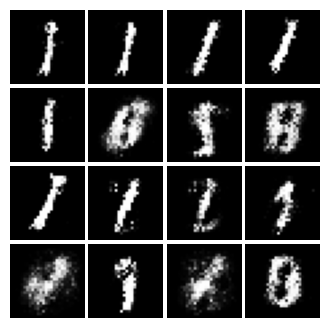
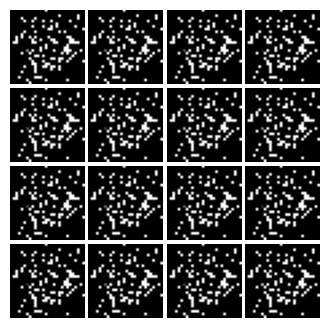

1. Image: with Logistic Loss we get some shape of the numbers, they might remember us for numbers
2. Image: with Vanilla the result is very bad there are not even shapes that could remember us for numbers it is a complete mess

Both of the images are after 5 epochs

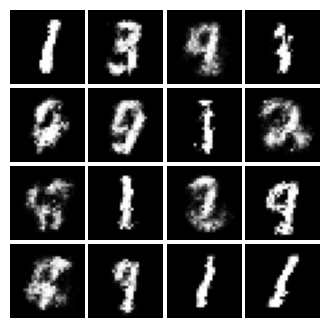
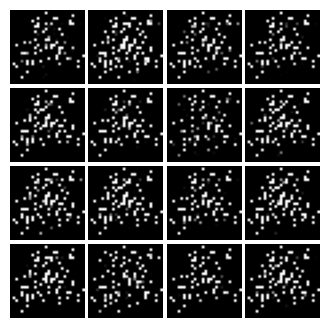

1. Image: with Logistic Loss the numbers are still noisy but we can recognize some of the numbers
2. Image: with Vanilla the numbers are a mess we still not recognize anything but there are less random white pixels

Both of the images are after 10 epochs. We also recognize that the Logistic Loss is way more faster than Vanilla

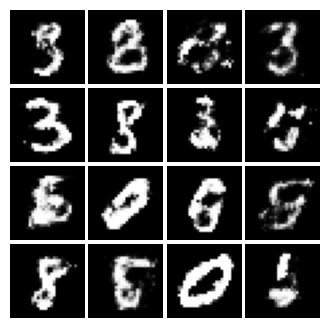
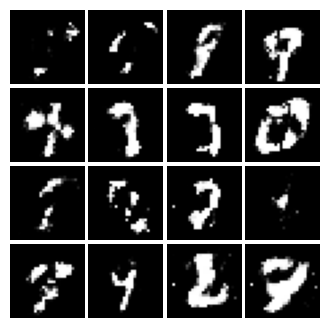

1. Image: Logistic Loss gave us recognizeable numbers in a really good quality it looks more stable and the generated random numbers are varied
2. Image: Vanilla's numbers are still barely recognizeable but now we recognize some of them we also noticed that Vanilla is a little bit unstable and it might have a repetitive pattern

Both of the images were taken after 50 epochs

Why is the output different for both cases?

Vanilla uses BCE loss + sigmoid and there is a bigger chance for the vanishing gradient problem in this model. If the discriminator is too good at distinguishing real and generated images then there is almost no gradient feedback it can lead to unstable training.

Logistic Loss works directly on logits so it will be more stable and providing better more useful gradients even when the discriminator performs well.



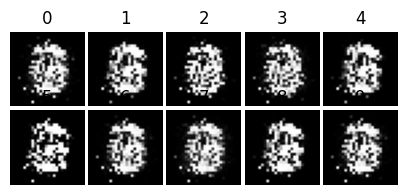
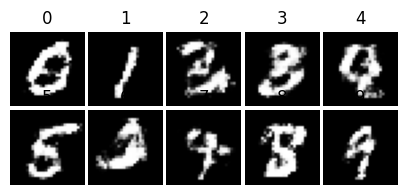
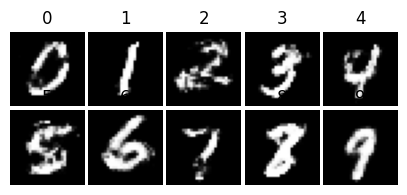

The first image is from the frist epoch the seconnd is from the 25th epoch and the last image is from the 50th epoch.
As we can see the model is a little bit unstable because on the second image we have more of one number but for the 50th epoch we got all of the numbers in really good quality and all of them recognizable. It is better than Vanilla or Logistic loss. It helped that we determined the numbers from 0 to 9.

We first trained a simple CNN on the MNIST dataset. After training we used this CNN to generate adversarial examples specifically making the network misclassify images of '4's as '9's. Then we  classified a random noise image to compare its output with the adversarial examples.

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2)
        self.dropout = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.dropout(self.conv2(x))))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

cnn_model = CNN().to(device)
print("CNN Model initialized:", cnn_model)

CNN Model initialized: CNN(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=320, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)


In [3]:
cnn_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

cnn_train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=cnn_transform, download=True)
cnn_test_dataset = datasets.MNIST(root='../MNIST', train=False, transform=cnn_transform, download=True)

cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=mb_size, shuffle=True)
cnn_test_loader = DataLoader(cnn_test_dataset, batch_size=mb_size, shuffle=False)

print("MNIST data loaded for CNN.")

MNIST data loaded for CNN.


In [4]:
def train_cnn(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

def test_cnn(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.0f}%)\n')
    return test_loss, correct / len(test_loader.dataset)

In [5]:
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.01)
cnn_epochs = 10

for epoch in range(1, cnn_epochs + 1):
    train_cnn(cnn_model, device, cnn_train_loader, cnn_optimizer, epoch)
    test_cnn(cnn_model, device, cnn_test_loader)

torch.save(cnn_model.state_dict(), "mnist_cnn.pt")
print("CNN Training complete and model saved as mnist_cnn.pt")

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.309525
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.709046
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.463318
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.304341
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.313794
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.285516
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.287797
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.333548
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.423900
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.243059

Test set: Average loss: 0.1402, Accuracy: 9576/10000 (96%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.529320
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.167308
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.330352
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.301291
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.630790
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.751851
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.586934
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.272259
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.258627
T

Here we implement the Fast Gradient Sign Method to create adversarial perturbations(little changes in the pixels). The goal is to modify an input image such that the trained CNN misclassifies it as a different target class.

Generating TARGETED adversarial example with epsilon = 0.2 to misclassify '4' as '9'


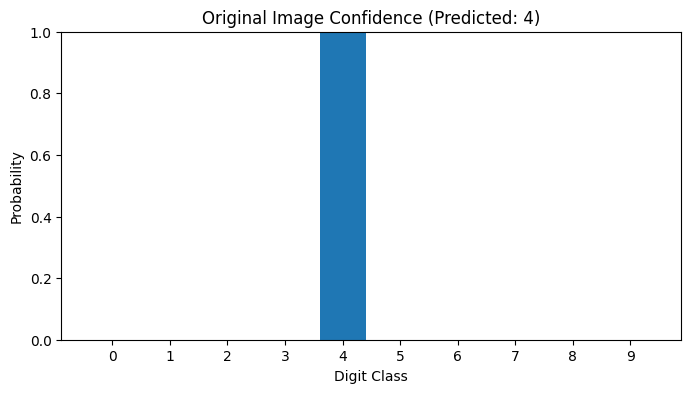

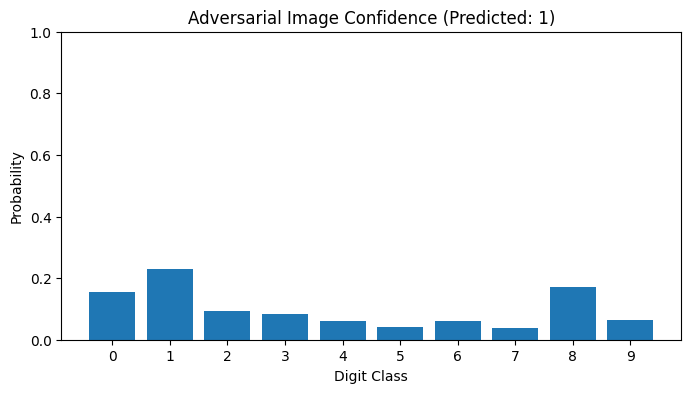

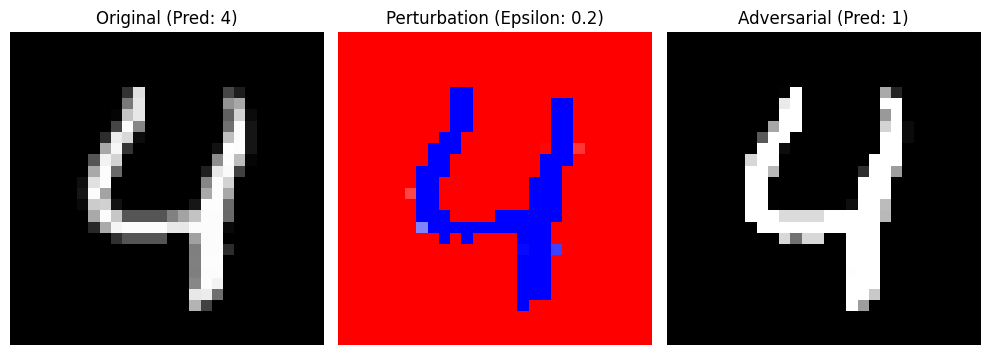

Original image classified as: 4
Adversarial image classified as: 1


In [ ]:
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image - epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1) 
    return perturbed_image

def plot_confidence(output, title):
    probabilities = F.softmax(output, dim=1).squeeze().cpu().detach().numpy()
    plt.figure(figsize=(8, 4))
    plt.bar(range(10), probabilities)
    plt.xticks(range(10))
    plt.title(title)
    plt.xlabel("Digit Class")
    plt.ylabel("Probability")
    plt.ylim(0, 1)
    plt.show()

def generate_and_classify_adversarial(model, device, test_loader, epsilon, target_class=9):
    model.eval()
    data_4 = None
    original_target_4 = None


    for i in range(len(test_loader.dataset)):
        img, label = test_loader.dataset[i]
        if label == 4:
            data_4 = img.unsqueeze(0).to(device)
            original_target_4 = torch.tensor([label]).to(device)
            break

    if data_4 is None:
        print("No image of digit 4 found in the test set. This should not happen for MNIST.")
        return

    data_4.requires_grad = True

    output = model(data_4)
    init_pred = output.argmax(dim=1, keepdim=True)

    if init_pred.item() != 4:
        print(f"Initial classification for chosen '4' is not 4 (it's {init_pred.item()}). Skipping adversarial generation.")
        return

    plot_confidence(output, f"Original Image Confidence (Predicted: {init_pred.item()})")

    target_label_tensor = torch.tensor([target_class], device=device)
    loss = F.nll_loss(output, target_label_tensor)

    model.zero_grad()

    loss.backward()

    data_grad = data_4.grad.data

    perturbed_data = fgsm_attack(data_4, epsilon, data_grad)

    output_perturbed = model(perturbed_data)
    final_pred = output_perturbed.argmax(dim=1, keepdim=True)

    plot_confidence(output_perturbed, f"Adversarial Image Confidence (Predicted: {final_pred.item()})")

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"Original (Pred: {init_pred.item()})")
    plt.imshow(data_4.cpu().squeeze().detach().numpy(), cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title(f"Perturbation (Epsilon: {epsilon})")
    perturbation = (perturbed_data - data_4).cpu().squeeze().detach().numpy()
    plt.imshow(perturbation, cmap='bwr', vmin=-epsilon, vmax=epsilon)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title(f"Adversarial (Pred: {final_pred.item()})")
    plt.imshow(perturbed_data.cpu().squeeze().detach().numpy(), cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Original image classified as: {init_pred.item()}")
    print(f"Adversarial image classified as: {final_pred.item()}")

epsilon = 0.2
target_class_for_attack = 9
print(f"Generating TARGETED adversarial example with epsilon = {epsilon} to misclassify '4' as '{target_class_for_attack}'")
generate_and_classify_adversarial(cnn_model, device, cnn_test_loader, epsilon, target_class=target_class_for_attack)


Creating Adversarial Examples:
Fast Gradient Sign Method is a quick and easy way to create adversarial examples. These are images that look exactly the same as the original to a human, but they totally trick the AI model.

How do they work:

The main idea is that neural networks are very sensitive to tiny changes in the image, so:

We start with a normal image  that the AI recognizes correctly.Then we pick a target number that we want the AI to see instead.

We check how we need to change each pixel of the image to make the AI think it is actually the target number. This tells us which direction to move the pixel values.

Then we take the direction of these changes and multiply it by a very small number called epsilon. We then add this noise to the original image. Epsilon controls how much we change the picture: if it is too high the AI gets tricked easily but humans might notice the change.

The Result - For example: the modified image still looks like a 4, but the AI will most likely say it is a 9.

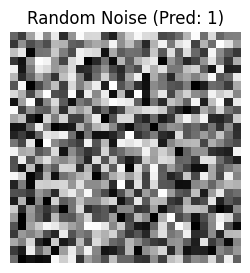

Random noise image classified as: 1
Comparison: Adversarial images are specifically crafted to trick the model, often resembling the original input, while random noise images lack any discernible pattern and are usually classified with low confidence, potentially as any class depending on random features picked up by the network.


In [7]:
random_noise = torch.rand(1, 1, 28, 28).to(device)
cnn_model.eval()
with torch.no_grad():
    output_noise = cnn_model(random_noise)
    pred_noise = output_noise.argmax(dim=1, keepdim=True)

plt.figure(figsize=(3, 3))
plt.title(f"Random Noise (Pred: {pred_noise.item()})")
plt.imshow(random_noise.cpu().squeeze().numpy(), cmap='gray')
plt.axis('off')
plt.show()

print(f"Random noise image classified as: {pred_noise.item()}")
print("Comparison: Adversarial images are specifically crafted to trick the model, often resembling the original input, while random noise images lack any discernible pattern and are usually classified with low confidence, potentially as any class depending on random features picked up by the network.")

Comparing Adversarial Examples and Random Noise
Adversarial Images:

Goal: These images are made on purpose to trick a trained model into picking a specific wrong answer. To us they look just like the original but they have tiny, calculated changes.

Content: They have a lot of information because they show a clear object but they are designed to mislead the AI.

Random Noise Images:

Goal: These are just random pixels. There is no pattern or real information in them.

Content: They have almost zero information for humans or the AI. Usually, the model is very unsure about what it sees or it just guesses a number that looks a bit like the noise.

The Comparison:

Adversarial examples show us that AI models do not see the world the same way we do. Even a tiny change that we can't see can cause a huge mistake. On the other hand random noise shows what the model thinks about a total mess. The model simply cannot understand noise but it is forced to misunderstand an adversarial image.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [9]:
num_diffusion_steps = 1000
beta_start = 1e-4
beta_end = 0.02
ddpm_epochs = 20
ddpm_lr = 1e-3
batch_size = 64
image_size = 28
image_channels = 1

print(f"DDPM Hyperparameters: steps={num_diffusion_steps}, epochs={ddpm_epochs}, lr={ddpm_lr}")

DDPM Hyperparameters: steps=1000, epochs=20, lr=0.001


In [10]:
ddpm_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

ddpm_train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=ddpm_transform, download=True)
ddpm_train_loader = DataLoader(ddpm_train_dataset, batch_size=batch_size, shuffle=True)

print("MNIST data loaded for DDPM, normalized to [-1, 1].")

MNIST data loaded for DDPM, normalized to [-1, 1].


In [16]:
class GaussianDiffusion:
    def __init__(self, num_diffusion_steps, beta_start, beta_end, device):
        self.num_diffusion_steps = num_diffusion_steps
        self.device = device

        self.betas = torch.linspace(beta_start, beta_end, num_diffusion_steps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        self.sqrt_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.posterior_variance = self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)

    def get_index_from_list(self, vals, t, x_shape):
        batch_size = t.shape[0]
        out = vals.gather(-1, t)
        return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

    def forward_diffusion(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphas_cumprod_t = self.get_index_from_list(self.sqrt_alphas_cumprod, t, x_start.shape)
        sqrt_one_minus_alphas_cumprod_t = self.get_index_from_list(
            self.sqrt_one_minus_alphas_cumprod, t, x_start.shape
        )
        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise, noise

ddpm_scheduler = GaussianDiffusion(num_diffusion_steps, beta_start, beta_end, device)
print("Gaussian Diffusion (Noise Scheduler) initialized.")

Gaussian Diffusion (Noise Scheduler) initialized.


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DDPMUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=32, y_dim=None):
        super(DDPMUNet, self).__init__()
        self.time_emb_dim = features * 4
        self.time_mlp = nn.Sequential(
            nn.Linear(self.time_emb_dim // 4, self.time_emb_dim),
            nn.ReLU(),
            nn.Linear(self.time_emb_dim, self.time_emb_dim)
        )

        self.label_emb = None
        if y_dim is not None:

            self.label_emb = nn.Sequential(
                nn.Linear(y_dim, self.time_emb_dim),
                nn.ReLU(),
                nn.Linear(self.time_emb_dim, self.time_emb_dim)
            )

        self.enc1 = self._block(in_channels, features)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self._block(features, features * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = self._block(features * 2, features * 4)
        self.upconv2 = nn.ConvTranspose2d(features * 4, features * 2, kernel_size=2, stride=2)
        self.dec2 = self._block(features * 4, features * 2)

        self.upconv1 = nn.ConvTranspose2d(features * 2, features, kernel_size=2, stride=2)
        self.dec1 = self._block(features * 2, features)

        self.final_conv = nn.Conv2d(features, out_channels, kernel_size=1)

    def _block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
    def forward(self, x, t, y=None):

        t_emb = self.time_mlp(t)
        y_emb = None
        if self.label_emb is not None and y is not None:
            y_emb = self.label_emb(y)

        combined_emb = t_emb
        if y_emb is not None:
            combined_emb = combined_emb + y_emb

        e1_down = self.enc1(x)
        p1 = self.pool1(e1_down)
        e2_down = self.enc2(p1)
        p2 = self.pool2(e2_down)
        b = self.bottleneck(p2)
        combined_emb_expanded = combined_emb.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, b.shape[-2], b.shape[-1])
        b = b + combined_emb_expanded


        d2_up = self.upconv2(b)
        d2 = torch.cat((d2_up, e2_down), dim=1)
        d2 = self.dec2(d2)

        d1_up = self.upconv1(d2)
        d1 = torch.cat((d1_up, e1_down), dim=1)
        d1 = self.dec1(d1)

        return self.final_conv(d1)

ddpm_model = DDPMUNet(in_channels=image_channels, out_channels=image_channels, features=32, y_dim=10).to(device)
print("DDPM U-Net model initialized with conditional capabilities.")

DDPM U-Net model initialized with conditional capabilities.


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

def train_ddpm(model, diffusion_scheduler, train_loader, optimizer, ddpm_epochs, device, y_dim):
    model.train()
    mse_loss = nn.MSELoss()
    for epoch in range(ddpm_epochs):
        total_loss = 0
        for step, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{ddpm_epochs}")):
            optimizer.zero_grad()

            images = images.to(device);
            batch_size = images.shape[0]
            labels_onehot = F.one_hot(labels, num_classes=y_dim).float().to(device)
            t = torch.randint(0, diffusion_scheduler.num_diffusion_steps, (batch_size,), device=device).long()
            noisy_images, noise = diffusion_scheduler.forward_diffusion(images, t)
            time_embedding_input = t.float() / diffusion_scheduler.num_diffusion_steps
            time_embedding_input = time_embedding_input.unsqueeze(-1).repeat(1, model.time_emb_dim // 4)

            predicted_noise = model(noisy_images, time_embedding_input, labels_onehot)
            loss = mse_loss(predicted_noise, noise)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{ddpm_epochs}, Loss: {avg_loss:.4f}")

    print("DDPM Training complete.")

    torch.save(model.state_dict(), "mnist_ddpm_unet.pth")
    print("DDPM model saved as mnist_ddpm_unet.pth")

In [19]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm


@torch.no_grad()
def sample_ddpm(model, diffusion_scheduler, num_samples, img_channels, img_size, device, filename="ddpm_samples.png", target_label=None):
    model.eval()

    x = torch.randn(num_samples, img_channels, img_size, img_size, device=device)
    labels_onehot = None
    is_conditional_model = model.label_emb is not None
    if is_conditional_model:
        if target_label is not None:

            labels_onehot = F.one_hot(torch.full((num_samples,), target_label, dtype=torch.long), num_classes=10).float().to(device)
        else:

            print("Warning: Conditional model sampling without target_label. Generating random digits for each sample.")
            labels_onehot = F.one_hot(torch.randint(0, 10, (num_samples,)), num_classes=10).float().to(device)
    elif target_label is not None:
        print("Warning: Target label provided, but the DDPM model is unconditional. Ignoring target_label.")

    for i in tqdm(reversed(range(0, diffusion_scheduler.num_diffusion_steps)), desc="Sampling", total=diffusion_scheduler.num_diffusion_steps):
        t = torch.full((num_samples,), i, device=device, dtype=torch.long)

        alpha_t = diffusion_scheduler.get_index_from_list(diffusion_scheduler.alphas, t, x.shape)
        sqrt_one_minus_alphas_cumprod_t = diffusion_scheduler.get_index_from_list(
            diffusion_scheduler.sqrt_one_minus_alphas_cumprod, t, x.shape
        )
        betas_t = diffusion_scheduler.get_index_from_list(diffusion_scheduler.betas, t, x.shape)
        sqrt_recip_alphas_t = diffusion_scheduler.get_index_from_list(diffusion_scheduler.sqrt_recip_alphas, t, x.shape)
        posterior_variance_t = diffusion_scheduler.get_index_from_list(diffusion_scheduler.posterior_variance, t, x.shape)
        time_embedding_input = t.float() / diffusion_scheduler.num_diffusion_steps
        time_embedding_input = time_embedding_input.unsqueeze(-1).repeat(1, model.time_emb_dim // 4)


        predicted_noise = model(x, time_embedding_input, labels_onehot)


        x_t_minus_1_mean = sqrt_recip_alphas_t * (x - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t)

        if i > 0:
            noise = torch.randn_like(x)
            x = x_t_minus_1_mean + torch.sqrt(posterior_variance_t) * noise
        else:
            x = x_t_minus_1_mean

    x = (x + 1) * 0.5
    x = torch.clamp(x, 0, 1)

    max_cols = 5
    num_cols = min(num_samples, max_cols)
    num_rows = (num_samples + num_cols - 1) // num_cols

    fig = plt.figure(figsize=(num_cols * 2, num_rows * 2))
    for i in range(num_samples):
        ax = plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(x[i].squeeze().cpu().numpy(), cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    print(f"Generated DDPM samples saved to {filename}")

Epoch 1/20: 100%|██████████| 938/938 [00:35<00:00, 26.41it/s]


Epoch 1/20, Loss: 0.0781


Epoch 2/20: 100%|██████████| 938/938 [00:34<00:00, 27.02it/s]


Epoch 2/20, Loss: 0.0536


Epoch 3/20: 100%|██████████| 938/938 [00:34<00:00, 26.94it/s]


...

Epoch 19/20: 100%|██████████| 938/938 [00:35<00:00, 26.69it/s]


Epoch 19/20, Loss: 0.0372


Epoch 20/20: 100%|██████████| 938/938 [00:35<00:00, 26.51it/s]


Epoch 20/20, Loss: 0.0369
DDPM Training complete.
DDPM model saved as mnist_ddpm_unet.pth
Generating samples for digit 0


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 302.50it/s]


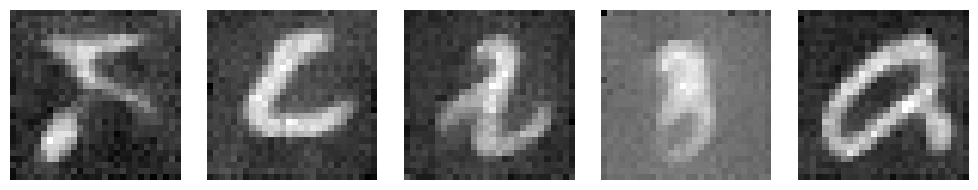

Generated DDPM samples saved to ddpm_mnist_generated_digit_0.png
Generating samples for digit 1


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 292.93it/s]


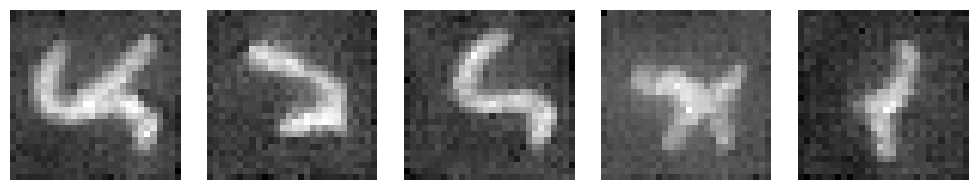

Generated DDPM samples saved to ddpm_mnist_generated_digit_1.png
Generating samples for digit 2


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 295.09it/s]


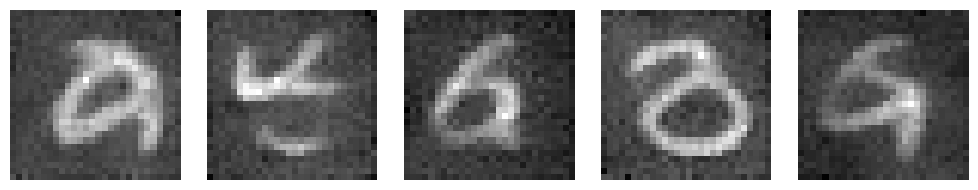

Generated DDPM samples saved to ddpm_mnist_generated_digit_2.png
Generating samples for digit 3


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 295.09it/s]


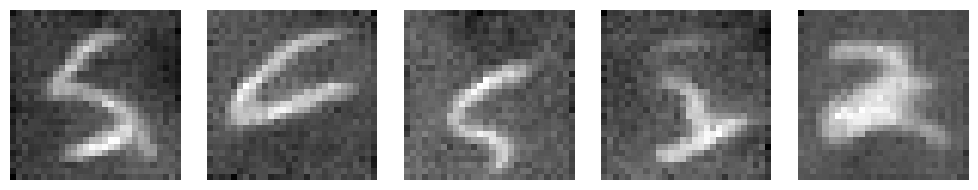

Generated DDPM samples saved to ddpm_mnist_generated_digit_3.png
Generating samples for digit 4


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 287.70it/s]


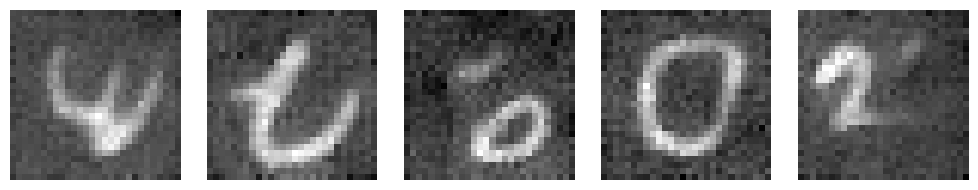

Generated DDPM samples saved to ddpm_mnist_generated_digit_4.png
Generating samples for digit 5


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 298.17it/s]


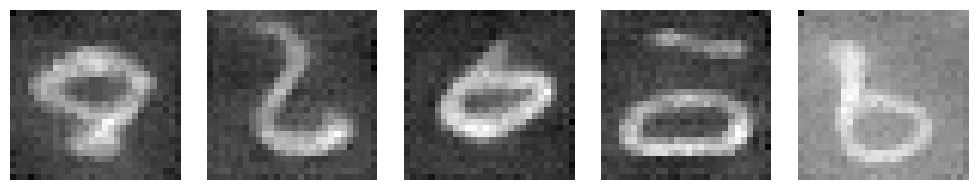

Generated DDPM samples saved to ddpm_mnist_generated_digit_5.png
Generating samples for digit 6


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 294.31it/s]


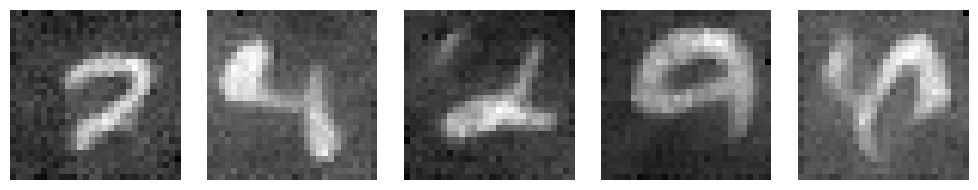

Generated DDPM samples saved to ddpm_mnist_generated_digit_6.png
Generating samples for digit 7


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 290.47it/s]


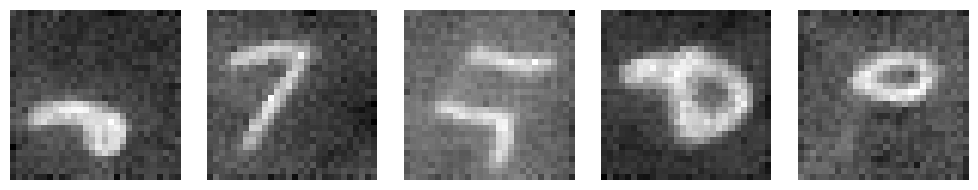

Generated DDPM samples saved to ddpm_mnist_generated_digit_7.png
Generating samples for digit 8


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 296.93it/s]


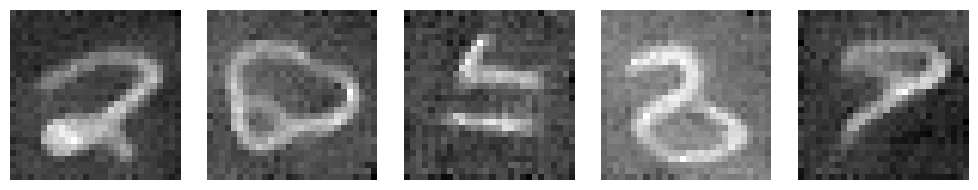

Generated DDPM samples saved to ddpm_mnist_generated_digit_8.png
Generating samples for digit 9


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 297.02it/s]


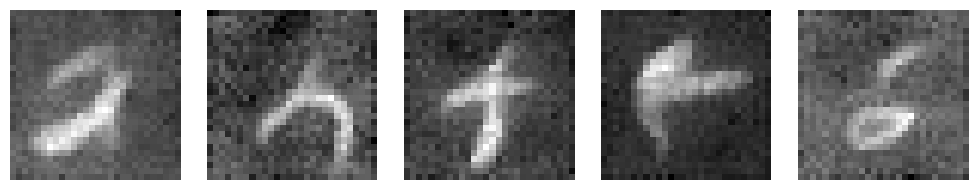

Generated DDPM samples saved to ddpm_mnist_generated_digit_9.png
Generating a batch of mixed conditional samples (random digits 0-9).


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 289.37it/s]


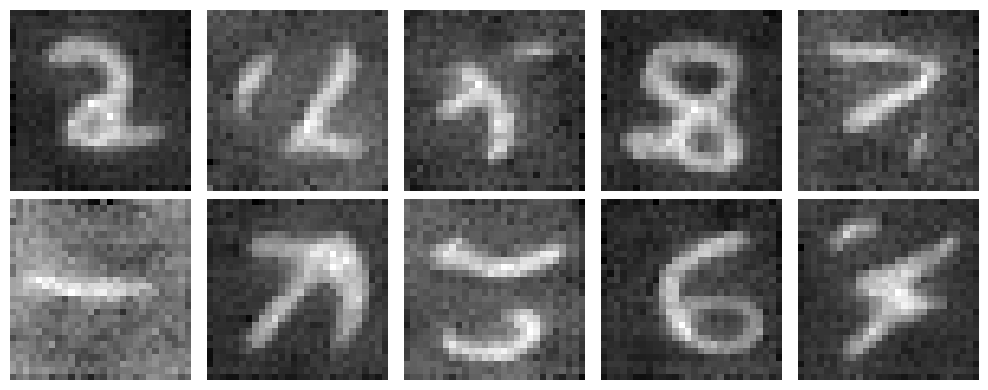

Generated DDPM samples saved to ddpm_mnist_generated_mixed.png


In [20]:
import torch.optim as optim
import torch

ddpm_optimizer = optim.Adam(ddpm_model.parameters(), lr=ddpm_lr)
y_dim_mnist = 10
train_ddpm(ddpm_model, ddpm_scheduler, ddpm_train_loader, ddpm_optimizer, ddpm_epochs, device, y_dim_mnist)

num_generated_samples = 10
for i in range(y_dim_mnist):
    print(f"Generating samples for digit {i}")
    sample_ddpm(ddpm_model, ddpm_scheduler, num_samples=5, img_channels=image_channels, img_size=image_size, device=device, filename=f"ddpm_mnist_generated_digit_{i}.png", target_label=i)

print("Generating a batch of mixed conditional samples (random digits 0-9).")
sample_ddpm(ddpm_model, ddpm_scheduler, num_samples=10, img_channels=image_channels, img_size=image_size, device=device, filename="ddpm_mnist_generated_mixed.png", target_label=None)

Epoch 1/20: 100%|██████████| 938/938 [00:36<00:00, 25.93it/s]


Epoch 1/20, Loss: 0.0372


Epoch 2/20: 100%|██████████| 938/938 [00:35<00:00, 26.63it/s]


Epoch 2/20, Loss: 0.0368


Epoch 3/20: 100%|██████████| 938/938 [00:35<00:00, 26.51it/s]


...

Epoch 19/20: 100%|██████████| 938/938 [00:34<00:00, 26.81it/s]


Epoch 19/20, Loss: 0.0351


Epoch 20/20: 100%|██████████| 938/938 [00:34<00:00, 26.86it/s]


Epoch 20/20, Loss: 0.0355
DDPM Training complete.
DDPM model saved as mnist_ddpm_unet.pth
Generating samples for digit 0


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 305.08it/s]


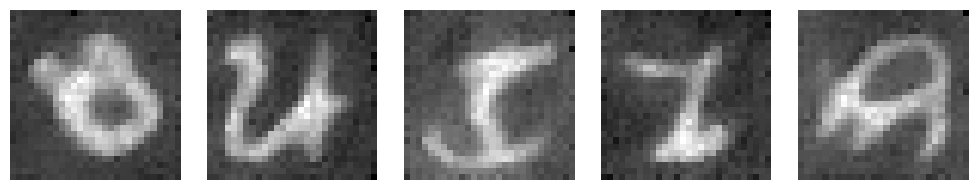

Generated DDPM samples saved to ddpm_mnist_generated_digit_0.png
Generating samples for digit 1


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 297.91it/s]


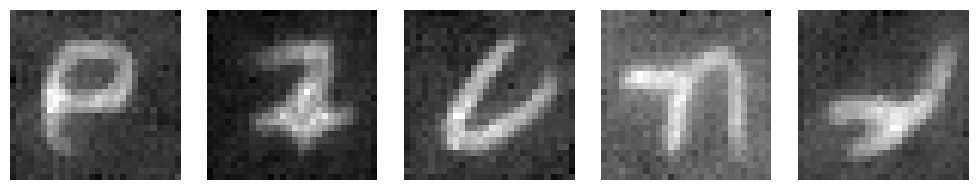

Generated DDPM samples saved to ddpm_mnist_generated_digit_1.png
Generating samples for digit 2


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 293.70it/s]


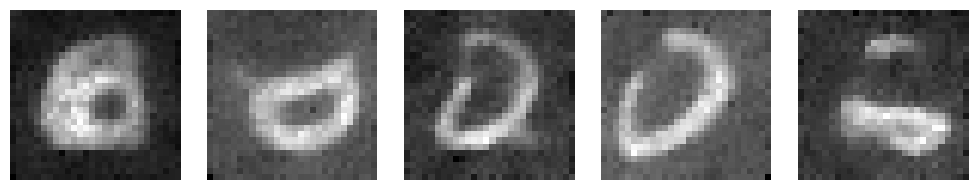

Generated DDPM samples saved to ddpm_mnist_generated_digit_2.png
Generating samples for digit 3


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 298.62it/s]


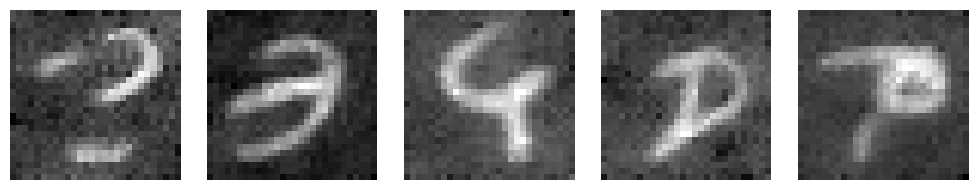

Generated DDPM samples saved to ddpm_mnist_generated_digit_3.png
Generating samples for digit 4


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 293.45it/s]


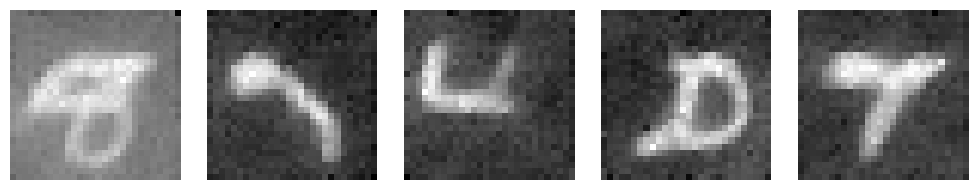

Generated DDPM samples saved to ddpm_mnist_generated_digit_4.png
Generating samples for digit 5


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 298.26it/s]


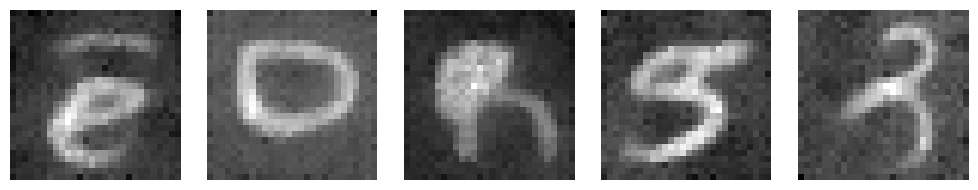

Generated DDPM samples saved to ddpm_mnist_generated_digit_5.png
Generating samples for digit 6


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 299.87it/s]


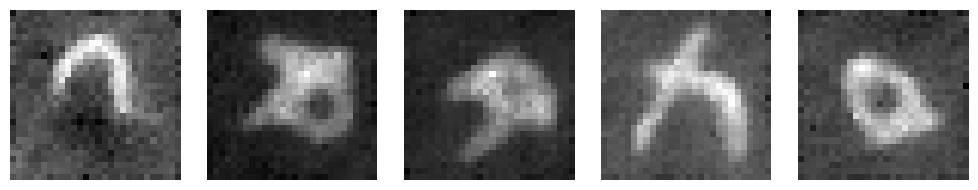

Generated DDPM samples saved to ddpm_mnist_generated_digit_6.png
Generating samples for digit 7


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 297.55it/s]


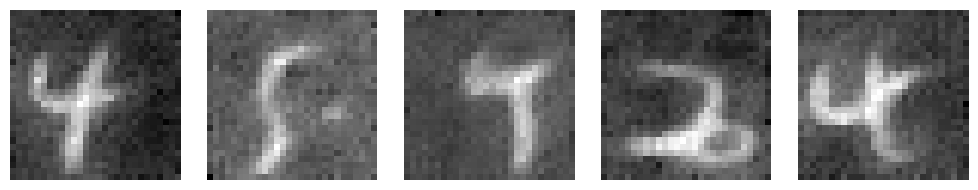

Generated DDPM samples saved to ddpm_mnist_generated_digit_7.png
Generating samples for digit 8


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 293.19it/s]


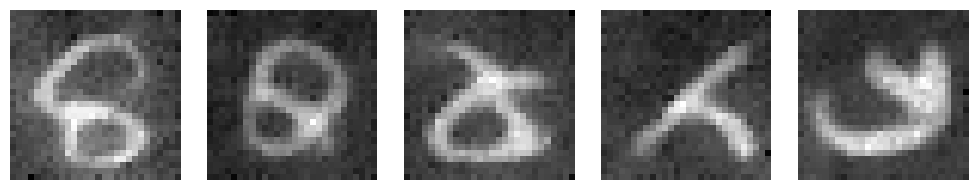

Generated DDPM samples saved to ddpm_mnist_generated_digit_8.png
Generating samples for digit 9


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 301.04it/s]


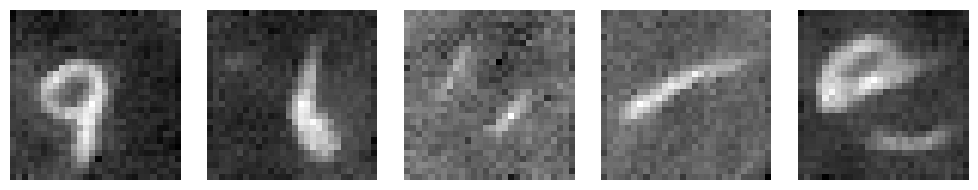

Generated DDPM samples saved to ddpm_mnist_generated_digit_9.png
Generating a batch of mixed conditional samples (random digits 0-9).


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 298.17it/s]


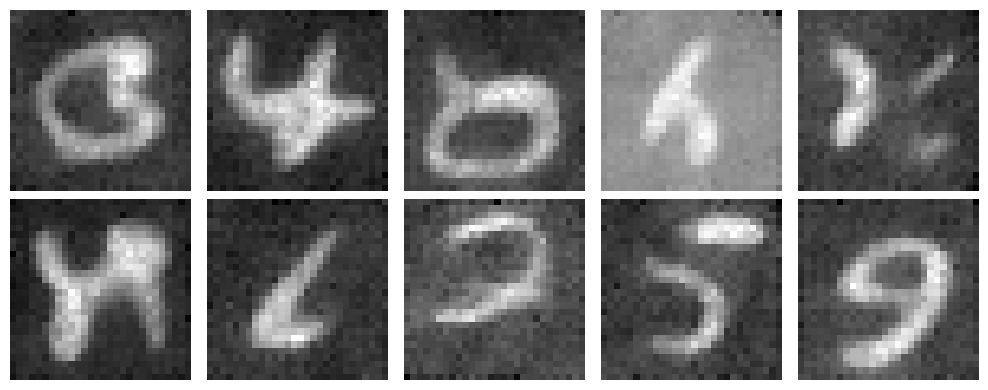

Generated DDPM samples saved to ddpm_mnist_generated_mixed.png


In [21]:
import torch.optim as optim
import torch


ddpm_optimizer = optim.Adam(ddpm_model.parameters(), lr=ddpm_lr)
y_dim_mnist = 10

train_ddpm(ddpm_model, ddpm_scheduler, ddpm_train_loader, ddpm_optimizer, ddpm_epochs, device, y_dim_mnist)
num_generated_samples = 10
for i in range(y_dim_mnist):
    print(f"Generating samples for digit {i}")
    sample_ddpm(ddpm_model, ddpm_scheduler, num_samples=5, img_channels=image_channels, img_size=image_size, device=device, filename=f"ddpm_mnist_generated_digit_{i}.png", target_label=i)


print("Generating a batch of mixed conditional samples (random digits 0-9).")
sample_ddpm(ddpm_model, ddpm_scheduler, num_samples=10, img_channels=image_channels, img_size=image_size, device=device, filename="ddpm_mnist_generated_mixed.png", target_label=None)

GAN vs. Stable Diffusion:
Both GANs and Diffusion models are powerful tools for generating data but they use different logic and math.

GANs:

Mechanism: It is a zero-sum process between two networks. The Generator creates images, and the Discriminator tries to catch the fakes.

Training: It can be very unstable. A common problem is mode collapse where the Generator keeps making the same image over and over.

Generation: Very fast, it uses a single-step process to turn a noise vector into an image.

Results: The images are sharp but sometimes they have visual errors because of the adversarial training.

DDPMs:

Mechanism: It uses a forward and reverse process. First, it adds Gaussian noise to an image until it is destroyed. Then, a U-Net learns to remove this noise step-by-step to rebuild the original image.

Training: Much more stable than GANs. It uses MSE loss to predict the noise, which is easier to optimize.

Generation: It is an iterative process, meaning it takes many steps to create one image. This makes it much slower than a GAN.

Results: Usually higher quality and more diverse. It is less likely to suffer from mode collapse.

Key Differences for MNIST:

Conditioning: In our CGAN, we use a label to tell the model exactly which digit to generate. In a basic DDPM the model picks a random digit from the distribution unless we add a specific conditional input to the U-Net.

Texture: DDPMs usually produce smoother images, while GANs can sometimes look noisier because of the competition between the networks.